# v12 data + fit plots

Observed titration data vs. the fitted 4PL dose-response curve, for a handful of representative `(run_id, mab_virus)` curves, for the v12 models that have actually finished so far: `m4b/m0`, `m5b/m0`, `m5b/m1`.

**Structure recap** (see `4PL_plate_fit_with_estimates_v12*.txt` / the mlxtran `[INDIVIDUAL]` blocks for the full spec):
- Two observation streams: `binary_cc==1` -> `RLU_cc = L_plate` (plate background/control level), `binary_cc==0` -> `RLU_sample_vc` (the titration curve we care about here).
- `h`, `f`, `L_gap` vary by `(mab_virus, goes_down)`, with a random effect.
- `L_plate`, `U`, `alpha` (and `m`, m5b only) vary by `run_id` only, no random effect.
- Edge correction: `E_ij = 1 - alpha*(exp(-plate_row) + exp(-(9-plate_row)) + exp(-plate_col) + exp(-(13-plate_col)) - 2*exp(-4.5) - 2*exp(-6.5))`, plus `+ m*(plate_row - 4.5)` for m5b.
- `L = L_plate + exp(L_gap)`; `RLU_sample_vc = L + (U - L) / (1 + exp(h*(log(concentration) - log(f)))) * E_ij`.

**Excluded: `m4b/m1`.** Its log shows `COMPLETE` after 0.0 minutes, but it produced no output at all -- no `IndividualParameters/`, `LogLikelihood/`, `populationParameters.txt`, or `m1_fitted.mlxtran`. That looks like a silent failure on rsrv (or a stale `_complete.flag`/cached-session artifact), not a real fit. Worth checking before trusting anything from it; add it back to `MODELS` below once it has real output.

**Heads-up on `m4b/m0`:** its fitted `L_gap_mode` is enormous and negative (~-4.6e5), so `exp(L_gap) ~= 0` and `L ~= L_plate` -- the `L_gap` term is essentially inert for this fit. Not fixed here, just flagging it so a flat-looking lower asymptote isn't a surprise.

**Note on `id`:** each `id` (e.g. `411|4`) looks like it's a per-plate/run_id subject index, and not every one of those has titration (`binary_cc==0`) rows -- some look like blank/control-only wells with background (`binary_cc==1`) observations only. The curve-picking below filters those out before choosing what to plot.

Run this under the `stan` WSL venv (`source ~/envs/stan/bin/activate`) -- same environment used for the rest of this project's Python tooling.

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("/mnt/c/Users/bhaddock/repos/titration_pnlme/single_mabs")
DATA_PATH = BASE / "input_data/retagged_data/33_plates_m4b_m5b_estimates_2026-09-13.csv"

MODELS = {
    "m4b/m2": dict(
        params_path=BASE / "4PL_plate_fit_33_plates/v12/m4b/model_files/m2/IndividualParameters/estimatedIndividualParameters.txt",
        has_m=False,
    ),
    "m4b/m3": dict(
        params_path=BASE / "4PL_plate_fit_33_plates/v12/m4b/model_files/m3/IndividualParameters/estimatedIndividualParameters.txt",
        has_m=False,
    ),
    "m5b/m2": dict(
        params_path=BASE / "4PL_plate_fit_33_plates/v12/m5b/model_files/m2/IndividualParameters/estimatedIndividualParameters.txt",
        has_m=True,
    ),
    "m5b/m3": dict(
        params_path=BASE / "4PL_plate_fit_33_plates/v12/m5b/model_files/m3/IndividualParameters/estimatedIndividualParameters.txt",
        has_m=True,
    ),
    "m5b/m4": dict(
        params_path=BASE / "4PL_plate_fit_33_plates/v12/m5b/model_files/m4/IndividualParameters/estimatedIndividualParameters.txt",
        has_m=True,
    ),    # m4b/m1 excluded -- see markdown above, it never produced real output.
}

N_CURVES = 12  # how many representative (run_id, mab_virus) curves to plot per model

In [44]:
# Only the columns the plotting below actually needs.
DATA_COLS = ["id", "concentration", "rlu", "run_id", "mab_virus", "binary_cc", "plate_row", "plate_col", "goes_down"]
data = pd.read_csv(DATA_PATH, usecols=DATA_COLS)
data["binary_cc"] = data["binary_cc"].astype(int)
data.head()

,id,concentration,rlu,run_id,mab_virus,binary_cc,plate_row,plate_col,goes_down
0,411|4,0.045725,53482.0,411,70.0|274,0,1,4,True
1,411|3,0.137174,40956.0,411,70.0|274,0,2,3,True
2,411|3,0.411523,25675.0,411,70.0|274,0,3,3,True
3,411|3,1.234568,7926.0,411,70.0|274,0,4,3,True
4,411|3,3.703704,2156.0,411,70.0|274,0,5,3,True


In [45]:
def edge_correction(alpha, plate_row, plate_col, m=None):
    """E_ij per the [LONGITUDINAL] EQUATION block in the m4b/m5b structural-model .txt files.
    At the plate center (row=4.5, col=6.5) this is exactly 1 -- both terms vanish there."""
    e = 1 - alpha * (
        np.exp(-plate_row) + np.exp(-(9 - plate_row))
        + np.exp(-plate_col) + np.exp(-(13 - plate_col))
        - 2 * np.exp(-4.5) - 2 * np.exp(-6.5)
    )
    if m is not None:
        e = e + m * (plate_row - 4.5)
    return e


def fit_curve(conc, p):
    """RLU_sample_vc at the plate CENTER (E_ij == 1, m-term == 0) -- the 'clean'
    dose-response curve with no edge effect, for overlaying on the raw / edge-
    corrected data (which does carry the real per-well edge effect)."""
    L = p["L_plate_mode"] + np.exp(p["L_gap_mode"])
    U = p["U_mode"]
    return L + (U - L) / (1 + np.exp(p["h_mode"] * (np.log(conc) - np.log(p["f_mode"]))))

In [46]:
def load_params(params_path):
    """One row per fitted id, keeping the *_mode point estimates plus the
    covariates that determine them (run_id/mab_virus/goes_down) -- used for
    labeling and for picking which curves to plot."""
    df = pd.read_csv(params_path)
    keep = ["id", "run_id", "mab_virus", "goes_down",
            "h_mode", "f_mode", "L_gap_mode", "L_plate_mode", "U_mode", "alpha_mode"]
    if "m_mode" in df.columns:
        keep.append("m_mode")
    return df[keep].drop_duplicates("id").set_index("id")

In [47]:
def pick_representative_ids(params, valid_ids, n=N_CURVES):
    """Cheap stand-in for 'representative': n ids spread evenly across the
    fitted f_mode (potency) range, restricted to ids that actually have
    plottable titration data (see `valid_ids`, built in merge_model from the
    binary_cc==0 rows). Swap this out freely -- e.g.
    params.loc[valid_ids].sample(n, random_state=0) for a random sample, or a
    hardcoded id list to look at something specific."""
    ordered = params.loc[params.index.intersection(valid_ids)].sort_values("f_mode")
    if ordered.empty:
        return []
    n = min(n, len(ordered))
    idx = np.linspace(0, len(ordered) - 1, n).round().astype(int)
    return ordered.index[idx].tolist()

In [48]:
def merge_model(model_key):
    """sample_vc rows for the ids this model actually fit, with the edge
    correction applied so `rlu_corrected` is comparable to `fit_curve`."""
    cfg = MODELS[model_key]
    params = load_params(cfg["params_path"])

    sub = data[data["id"].isin(params.index) & (data["binary_cc"] == 0) & (data["concentration"] > 0)].copy()
    sub = sub.drop(columns=["run_id", "mab_virus", "goes_down"])  # re-attached from `params` on join, avoids _x/_y dupes
    sub = sub.join(params, on="id")

    m = sub["m_mode"] if cfg["has_m"] else None
    sub["E_ij"] = edge_correction(sub["alpha_mode"], sub["plate_row"], sub["plate_col"], m)
    sub["rlu_corrected"] = sub["rlu"] / sub["E_ij"]
    return sub, params

In [49]:
def plot_model(model_key, n_ids=N_CURVES, save=True):
    sub, params = merge_model(model_key)
    valid_ids = sub["id"].unique()
    ids = pick_representative_ids(params, valid_ids, n_ids)

    ncols = 3
    nrows = max(1, -(-len(ids) // ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

    for ax, curve_id in zip(axes.flat, ids):
        g = sub[sub["id"] == curve_id].sort_values("concentration")
        p = params.loc[curve_id]

        if g.empty or (g["concentration"] > 0).sum() == 0:
            # Shouldn't happen given pick_representative_ids filters on valid_ids,
            # but degrade gracefully instead of crashing set_xscale('log') on empty data.
            ax.set_visible(False)
            continue

        ax.scatter(g["concentration"], g["rlu"], s=18, alpha=0.35, label="observed (raw)")
        ax.scatter(g["concentration"], g["rlu_corrected"], s=18, alpha=0.85, label="observed (edge-corrected)")

        conc_grid = np.geomspace(g["concentration"].min(), g["concentration"].max(), 200)
        ax.plot(conc_grid, fit_curve(conc_grid, p), "k-", lw=1.5, label="fit (plate center)")
        ax.axhline(p["L_plate_mode"], color="gray", ls="--", lw=0.8, label="L_plate")

        ax.set_xscale("log")
        ax.set_title(f"{curve_id}  |  mab_virus={p['mab_virus']}  run_id={p['run_id']}  goes_down={p['goes_down']}", fontsize=9)
        ax.set_xlabel("concentration")
        ax.set_ylabel("RLU")

    for ax in axes.flat[len(ids):]:
        ax.set_visible(False)

    visible_axes = [ax for ax in axes.flat if ax.get_visible()]
    if visible_axes:
        visible_axes[0].legend(fontsize=8, loc="best")
    fig.suptitle(f"{model_key} -- representative dose-response fits", y=1.02)
    fig.tight_layout()

    if save:
        out = BASE / "4PL_plate_fit_33_plates/v12" / f"{model_key.replace('/', '_')}_fits.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print("saved", out)

    return fig

In [50]:
def tmp(model_key, n_ids=N_CURVES, save=True):
    sub, params = merge_model(model_key)
    valid_ids = sub["id"].unique()
    ids = pick_representative_ids(params, valid_ids, n_ids)

    ncols = 3
    nrows = max(1, -(-len(ids) // ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

    return 
    for ax, curve_id in zip(axes.flat, ids):
        g = sub[sub["id"] == curve_id].sort_values("concentration")
        p = params.loc[curve_id]

        if g.empty or (g["concentration"] > 0).sum() == 0:
            # Shouldn't happen given pick_representative_ids filters on valid_ids,
            # but degrade gracefully instead of crashing set_xscale('log') on empty data.
            ax.set_visible(False)
            continue

        ax.scatter(g["concentration"], g["rlu"], s=18, alpha=0.35, label="observed (raw)")
        ax.scatter(g["concentration"], g["rlu_corrected"], s=18, alpha=0.85, label="observed (edge-corrected)")

        conc_grid = np.geomspace(g["concentration"].min(), g["concentration"].max(), 200)
        ax.plot(conc_grid, fit_curve(conc_grid, p), "k-", lw=1.5, label="fit (plate center)")
        ax.axhline(p["L_plate_mode"], color="gray", ls="--", lw=0.8, label="L_plate")

        ax.set_xscale("log")
        ax.set_title(f"{curve_id}  |  mab_virus={p['mab_virus']}  run_id={p['run_id']}  goes_down={p['goes_down']}", fontsize=9)
        ax.set_xlabel("concentration")
        ax.set_ylabel("RLU")

    for ax in axes.flat[len(ids):]:
        ax.set_visible(False)

    visible_axes = [ax for ax in axes.flat if ax.get_visible()]
    if visible_axes:
        visible_axes[0].legend(fontsize=8, loc="best")
    fig.suptitle(f"{model_key} -- representative dose-response fits", y=1.02)
    fig.tight_layout()

    if save:
        out = BASE / "4PL_plate_fit_33_plates/v12" / f"{model_key.replace('/', '_')}_fits.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print("saved", out)

    return fig

12

In [73]:
def fit_curve(conc, p):
    """RLU_sample_vc at the plate CENTER (E_ij == 1, m-term == 0) -- the 'clean'
    dose-response curve with no edge effect, for overlaying on the raw / edge-
    corrected data (which does carry the real per-well edge effect)."""
    L = p["L_plate_mode"] + np.exp(p["L_gap_mode"])
    U = p["U_mode"]
    return L + (U - L) / (1 + np.exp(p["h_mode"] * (np.log(conc) - np.log(p["f_mode"]))))

In [94]:
sub.loc[(sub.run_id==411) & (sub.plate_col==4)].sort_values(by='concentration').E_ij.to_numpy()

array([0.91558026, 0.93970832, 0.96382703, 0.98794215, 1.01205555,
       1.03616723, 1.06027532, 1.08437406])

In [100]:
sub.loc[(sub.run_id==411) & (sub.plate_col==4)].sort_values(by='concentration')

,id,concentration,rlu,binary_cc,plate_row,plate_col,run_id,mab_virus,goes_down,h_mode,f_mode,L_gap_mode,L_plate_mode,U_mode,alpha_mode,m_mode,E_ij,rlu_corrected
0,411|4,0.045725,53482.0,0,1,4,411,70.0|274,True,0.990545,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,0.915580,58413.229419
41,411|4,0.137174,45186.0,0,2,4,411,70.0|274,True,0.990545,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,0.939708,48085.133469
42,411|4,0.411523,36004.0,0,3,4,411,70.0|274,True,0.990545,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,0.963827,37355.250489
43,411|4,1.234568,15537.0,0,4,4,411,70.0|274,True,0.990545,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,0.987942,15726.629405
44,411|4,3.703704,4302.0,0,5,4,411,70.0|274,True,0.990545,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,1.012056,4250.754831
45,411|4,11.111111,1258.0,0,6,4,411,70.0|274,True,0.990545,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,1.036167,1214.089741
6,411|4,33.333333,948.0,0,7,4,411,70.0|274,True,0.990545,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,1.060275,894.107391
7,411|4,100.000000,850.0,0,8,4,411,70.0|274,True,0.990545,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,1.084374,783.862348


In [104]:
np.arange(2,13)

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [108]:
datapoints

array([54260., 45084., 27045., 12392.,  3032.,  1264.,   860.,   802.])

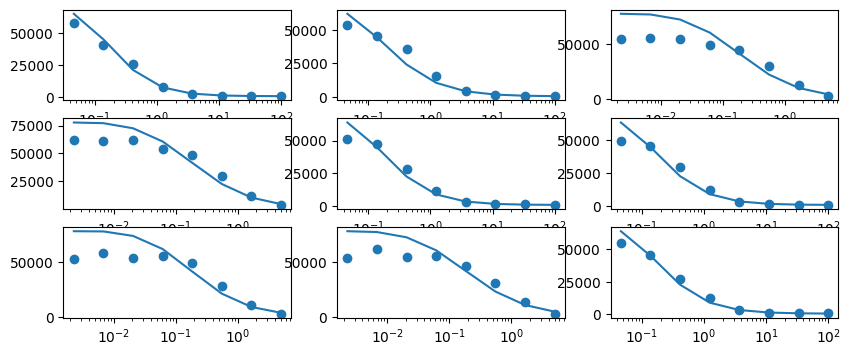

In [115]:
sub, params = merge_model("m5b/m3")

fig, axes = plt.subplots(3,3, figsize=(10, 4), squeeze=False)
axes = axes.flatten()
for col, ax in zip(np.arange(3,12), axes):
    Eij = sub.loc[(sub.run_id==411) & (sub.plate_col==col)].sort_values(by='concentration').E_ij.to_numpy()
    datapoints = sub.loc[(sub.run_id==411) & (sub.plate_col==col)].sort_values(by='concentration').rlu.to_numpy()
    pparam = params.query(f"id == '{411}|{col}'")
    if len(datapoints)>0:
        U, L_plate, L_gap, f, h = pparam[['U_mode','L_plate_mode','L_gap_mode','f_mode','h_mode']].values[0]
        L = L_plate + np.exp(L_gap)
        conc = sub.loc[sub.id==f"411|{col}"].sort_values(by='concentration').concentration.tolist()
        model = fit_curve(conc, {"U_mode":U, "L_plate_mode":L_plate, "L_gap_mode":L_gap, "h_mode":h, "f_mode":f})
        model = model*Eij
        ax.plot(conc, model)
        ax.scatter(conc, datapoints)
    ax.set_xscale("log")
plt.show()

In [116]:
sub.run_id.unique()

array([ 411,  783,  491,  433,  297,  183,  705,  555,  394, 1099,  611,
         84, 1042,  719,  863,  488,  152,  847, 1241,  474, 1056,  462,
       1159,   75, 1017,  291, 1197,   77,  745,  322, 1043,  963, 1260])

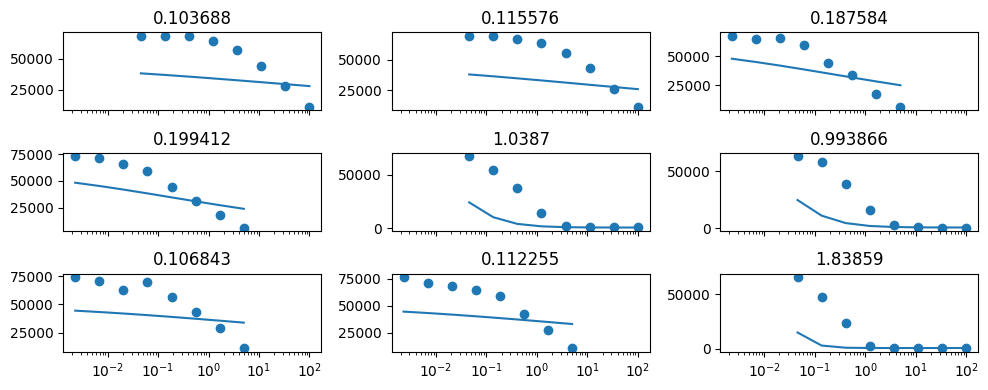

In [123]:
sub, params = merge_model("m5b/m3")

fig, axes = plt.subplots(3,3, figsize=(10, 4), sharex=True)
axes = axes.flatten()
run_id = 783
for col, ax in zip(np.arange(3,12), axes):
    Eij = sub.loc[(sub.run_id==run_id) & (sub.plate_col==col)].sort_values(by='concentration').E_ij.to_numpy()
    datapoints = sub.loc[(sub.run_id==run_id) & (sub.plate_col==col)].sort_values(by='concentration').rlu.to_numpy()
    pparam = params.query(f"id == '{run_id}|{col}'")
    if len(datapoints)>0:
        U, L_plate, L_gap, f, h = pparam[['U_mode','L_plate_mode','L_gap_mode','f_mode','h_mode']].values[0]
        L = L_plate + np.exp(L_gap)
        conc = sub.loc[sub.id==f"411|{col}"].sort_values(by='concentration').concentration.tolist()
        model = fit_curve(conc, {"U_mode":U, "L_plate_mode":L_plate, "L_gap_mode":L_gap, "h_mode":h, "f_mode":f})
        model = model*Eij
        ax.plot(conc, model)
        ax.scatter(conc, datapoints)
        ax.set_title(h)
    ax.set_xscale("log")
plt.tight_layout()
plt.show()

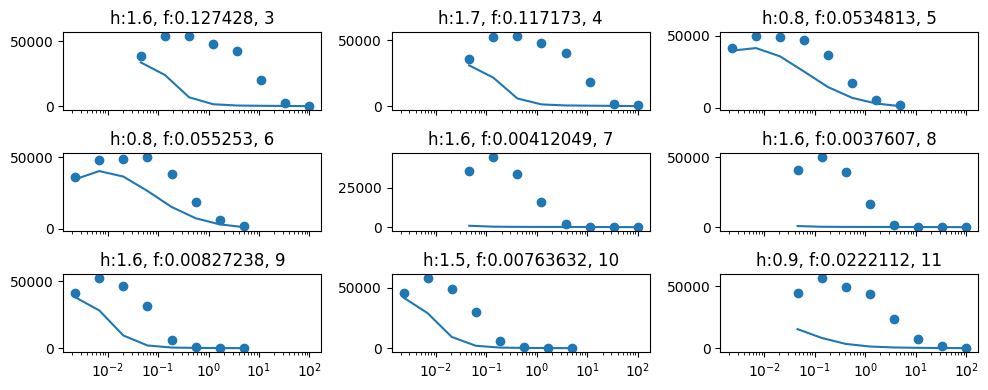

In [132]:
sub, params = merge_model("m5b/m4")

fig, axes = plt.subplots(3,3, figsize=(10, 4), sharex=True)
axes = axes.flatten()
run_id = 491
for col, ax in zip(np.arange(3,12), axes):
    Eij = sub.loc[(sub.run_id==run_id) & (sub.plate_col==col)].sort_values(by='concentration').E_ij.to_numpy()
    datapoints = sub.loc[(sub.run_id==run_id) & (sub.plate_col==col)].sort_values(by='concentration').rlu.to_numpy()
    pparam = params.query(f"id == '{run_id}|{col}'")
    if len(datapoints)>0:
        U, L_plate, L_gap, f, h = pparam[['U_mode','L_plate_mode','L_gap_mode','f_mode','h_mode']].values[0]
        L = L_plate + np.exp(L_gap)
        conc = sub.loc[sub.id==f"411|{col}"].sort_values(by='concentration').concentration.tolist()
        model = fit_curve(conc, {"U_mode":U, "L_plate_mode":L_plate, "L_gap_mode":L_gap, "h_mode":h, "f_mode":f})
        model = model*Eij
        ax.plot(conc, model)
        ax.scatter(conc, datapoints)
        ax.set_title(f"h:{str(h)[:3]}, f:{f}, {col}")
    ax.set_xscale("log")
plt.tight_layout()
plt.show()

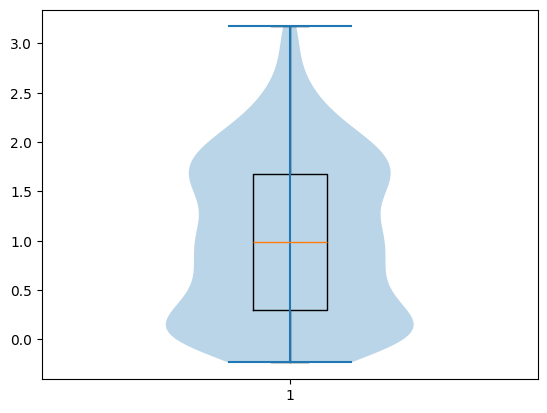

In [120]:
plt.boxplot(params.h_mode)
plt.violinplot(params.h_mode)
plt.show()

In [64]:
sub.head()

,id,concentration,rlu,binary_cc,plate_row,plate_col,run_id,mab_virus,goes_down,h_mode,f_mode,L_gap_mode,L_plate_mode,U_mode,alpha_mode,m_mode,E_ij,rlu_corrected
0,411|4,0.045725,53482.0,0,1,4,411,70.0|274,True,1.13876,0.249185,-321.17,528.305,84038.7,0.000006,0.021448,0.924929,57822.835332
1,411|3,0.137174,40956.0,0,2,3,411,70.0|274,True,1.10750,0.138386,-321.17,528.305,84038.7,0.000006,0.021448,0.946378,43276.565190
2,411|3,0.411523,25675.0,0,3,3,411,70.0|274,True,1.10750,0.138386,-321.17,528.305,84038.7,0.000006,0.021448,0.967827,26528.499511
3,411|3,1.234568,7926.0,0,4,3,411,70.0|274,True,1.10750,0.138386,-321.17,528.305,84038.7,0.000006,0.021448,0.989276,8011.923545
4,411|3,3.703704,2156.0,0,5,3,411,70.0|274,True,1.10750,0.138386,-321.17,528.305,84038.7,0.000006,0.021448,1.010724,2133.124710


In [85]:
params

,run_id,mab_virus,goes_down,h_mode,f_mode,L_gap_mode,L_plate_mode,U_mode,alpha_mode,m_mode
id,,,,,,,,,,
411|4,411,70.0|274,True,9.905450e-01,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|3,411,70.0|274,True,1.194810e+00,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|5,411,70.0|274,True,9.085630e-01,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|6,411,70.0|274,True,9.106230e-01,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|8,411,70.0|274,True,1.096470e+00,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
...,...,...,...,...,...,...,...,...,...,...
1260|9,1260,28.0|319,True,1.393350e+00,0.016232,-323.267,520.235,86708.7,0.000006,0.024115
1260|4,1260,22.0|319,True,1.449960e+00,0.033075,-324.763,520.235,86708.7,0.000006,0.024115
1260|3,1260,22.0|319,True,1.371610e+00,0.033075,-324.763,520.235,86708.7,0.000006,0.024115


In [69]:
conc = sub.loc[sub.id=="411|4"].sort_values(by='concentration').concentration.tolist()

In [77]:
sub.loc[(sub.run_id==411) & (sub.plate_col==3)]

,id,concentration,rlu,binary_cc,plate_row,plate_col,run_id,mab_virus,goes_down,h_mode,f_mode,L_gap_mode,L_plate_mode,U_mode,alpha_mode,m_mode,E_ij,rlu_corrected
1,411|3,0.137174,40956.0,0,2,3,411,70.0|274,True,1.19481,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,0.939706,43583.828693
2,411|3,0.411523,25675.0,0,3,3,411,70.0|274,True,1.19481,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,0.963825,26638.652097
3,411|3,1.234568,7926.0,0,4,3,411,70.0|274,True,1.19481,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,0.987940,8022.753101
4,411|3,3.703704,2156.0,0,5,3,411,70.0|274,True,1.19481,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,1.012054,2130.322031
5,411|3,11.111111,986.0,0,6,3,411,70.0|274,True,1.19481,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,1.036165,951.585673
40,411|3,0.045725,58138.0,0,1,3,411,70.0|274,True,1.19481,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,0.915578,63498.666639
46,411|3,33.333333,960.0,0,7,3,411,70.0|274,True,1.19481,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,1.060273,905.426900
47,411|3,100.000000,882.0,0,8,3,411,70.0|274,True,1.19481,0.162886,-321.354,520.231,86712.0,0.000063,0.024113,1.084372,813.373948


In [74]:
params.U_mode.unique()

array([ 86712. ,  86708.4,  86710.6,  86707. ,  86706.5,  28369.8,
        86711.5,  86713. ,  86711. ,  86710.9,  86708.8,  86710.5,
        86711.2,  86712.9,  86708.3,  86712.3,  86711.7,  86708.6,
        86710. ,  86708. , 105714. ,  86709.3,  86714. ,  86716.3,
        47197.4,  86708.7,  56372.4,  86711.4])

In [75]:
params.loc[params.run_id==411]

,run_id,mab_virus,goes_down,h_mode,f_mode,L_gap_mode,L_plate_mode,U_mode,alpha_mode,m_mode
id,,,,,,,,,,
411|4,411,70.0|274,True,9.905450e-01,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|3,411,70.0|274,True,1.194810e+00,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|5,411,70.0|274,True,9.085630e-01,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|6,411,70.0|274,True,9.106230e-01,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|8,411,70.0|274,True,1.096470e+00,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|7,411,70.0|274,True,1.109450e+00,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|9,411,70.0|274,True,9.794340e-01,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|10,411,70.0|274,True,8.860500e-01,0.162886,-321.354,520.231,86712.0,0.000063,0.024113
411|12,411,70.0|274,True,1.173190e+00,0.162886,-321.354,520.231,86712.0,0.000063,0.024113


In [51]:
df = merge_model("m5b/m0")[1]
df.U_mode.unique()

KeyError: 'm5b/m0'

In [37]:
df = merge_model("m4b/m0")[1]
df.U_mode.unique()

array([91033.3])

In [38]:
df = merge_model("m5b/m1")[1]
df.U_mode.unique()

array([88405.4])

In [40]:
df = pd.read_csv(
    '/mnt/c/Users/bhaddock/repos/titration_pnlme/single_mabs/4PL_plate_fit_33_plates/v12/m5b/model_files/m0/m0_fitted/In'
)

In [42]:
ls /mnt/c/Users/bhaddock/repos/titration_pnlme/single_mabs/4PL_plate_fit_33_plates/v12/m5b/model_files/m0/m0_fitted/

In [30]:
df[0].U_mode.unique()

array([91033.3])

saved /mnt/c/Users/bhaddock/repos/titration_pnlme/single_mabs/4PL_plate_fit_33_plates/v12/m4b_m2_fits.png


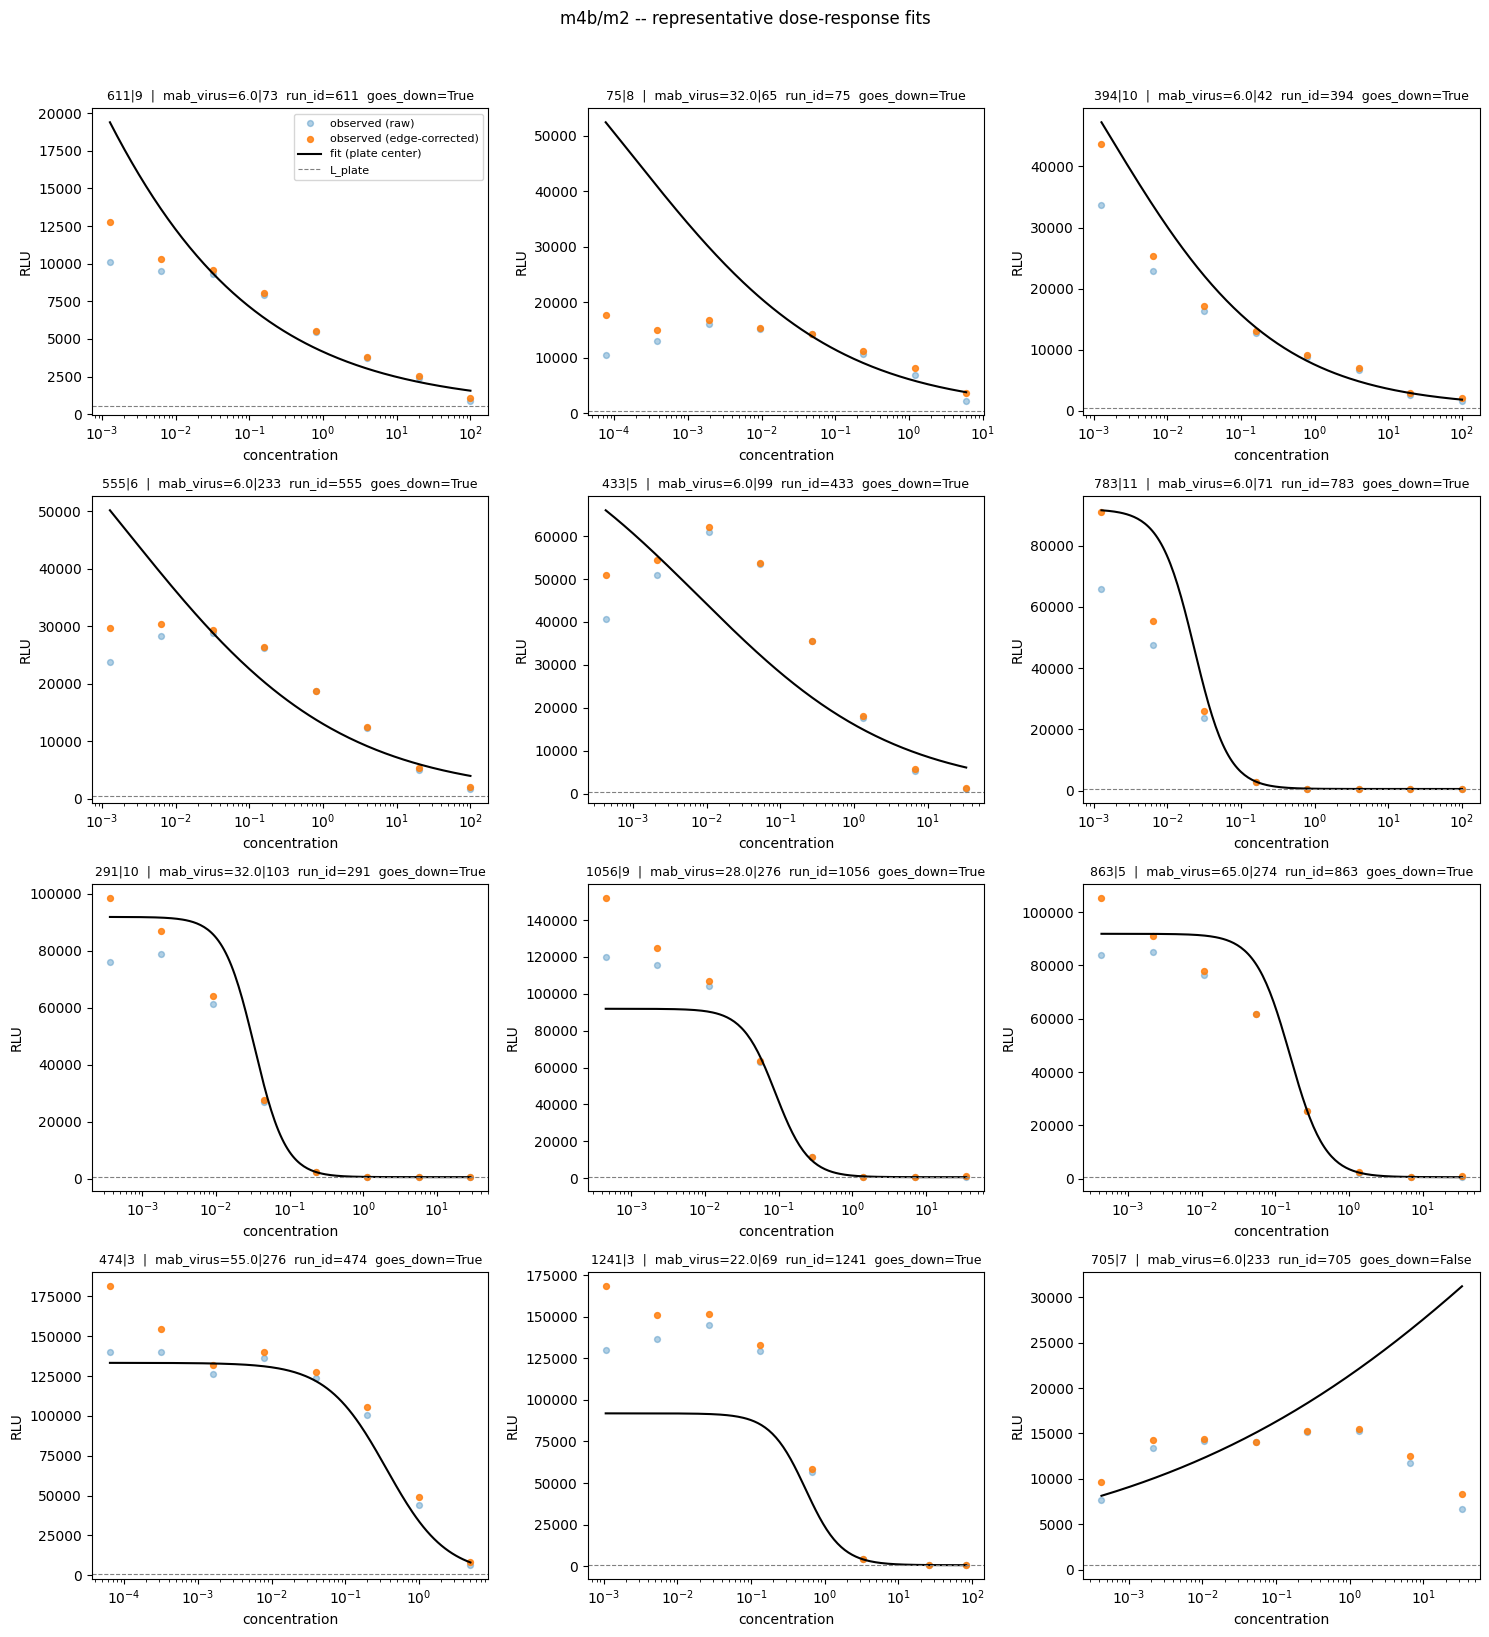

In [52]:
fig = plot_model("m4b/m2", n_ids=12)

saved /mnt/c/Users/bhaddock/repos/titration_pnlme/single_mabs/4PL_plate_fit_33_plates/v12/m4b_m3_fits.png


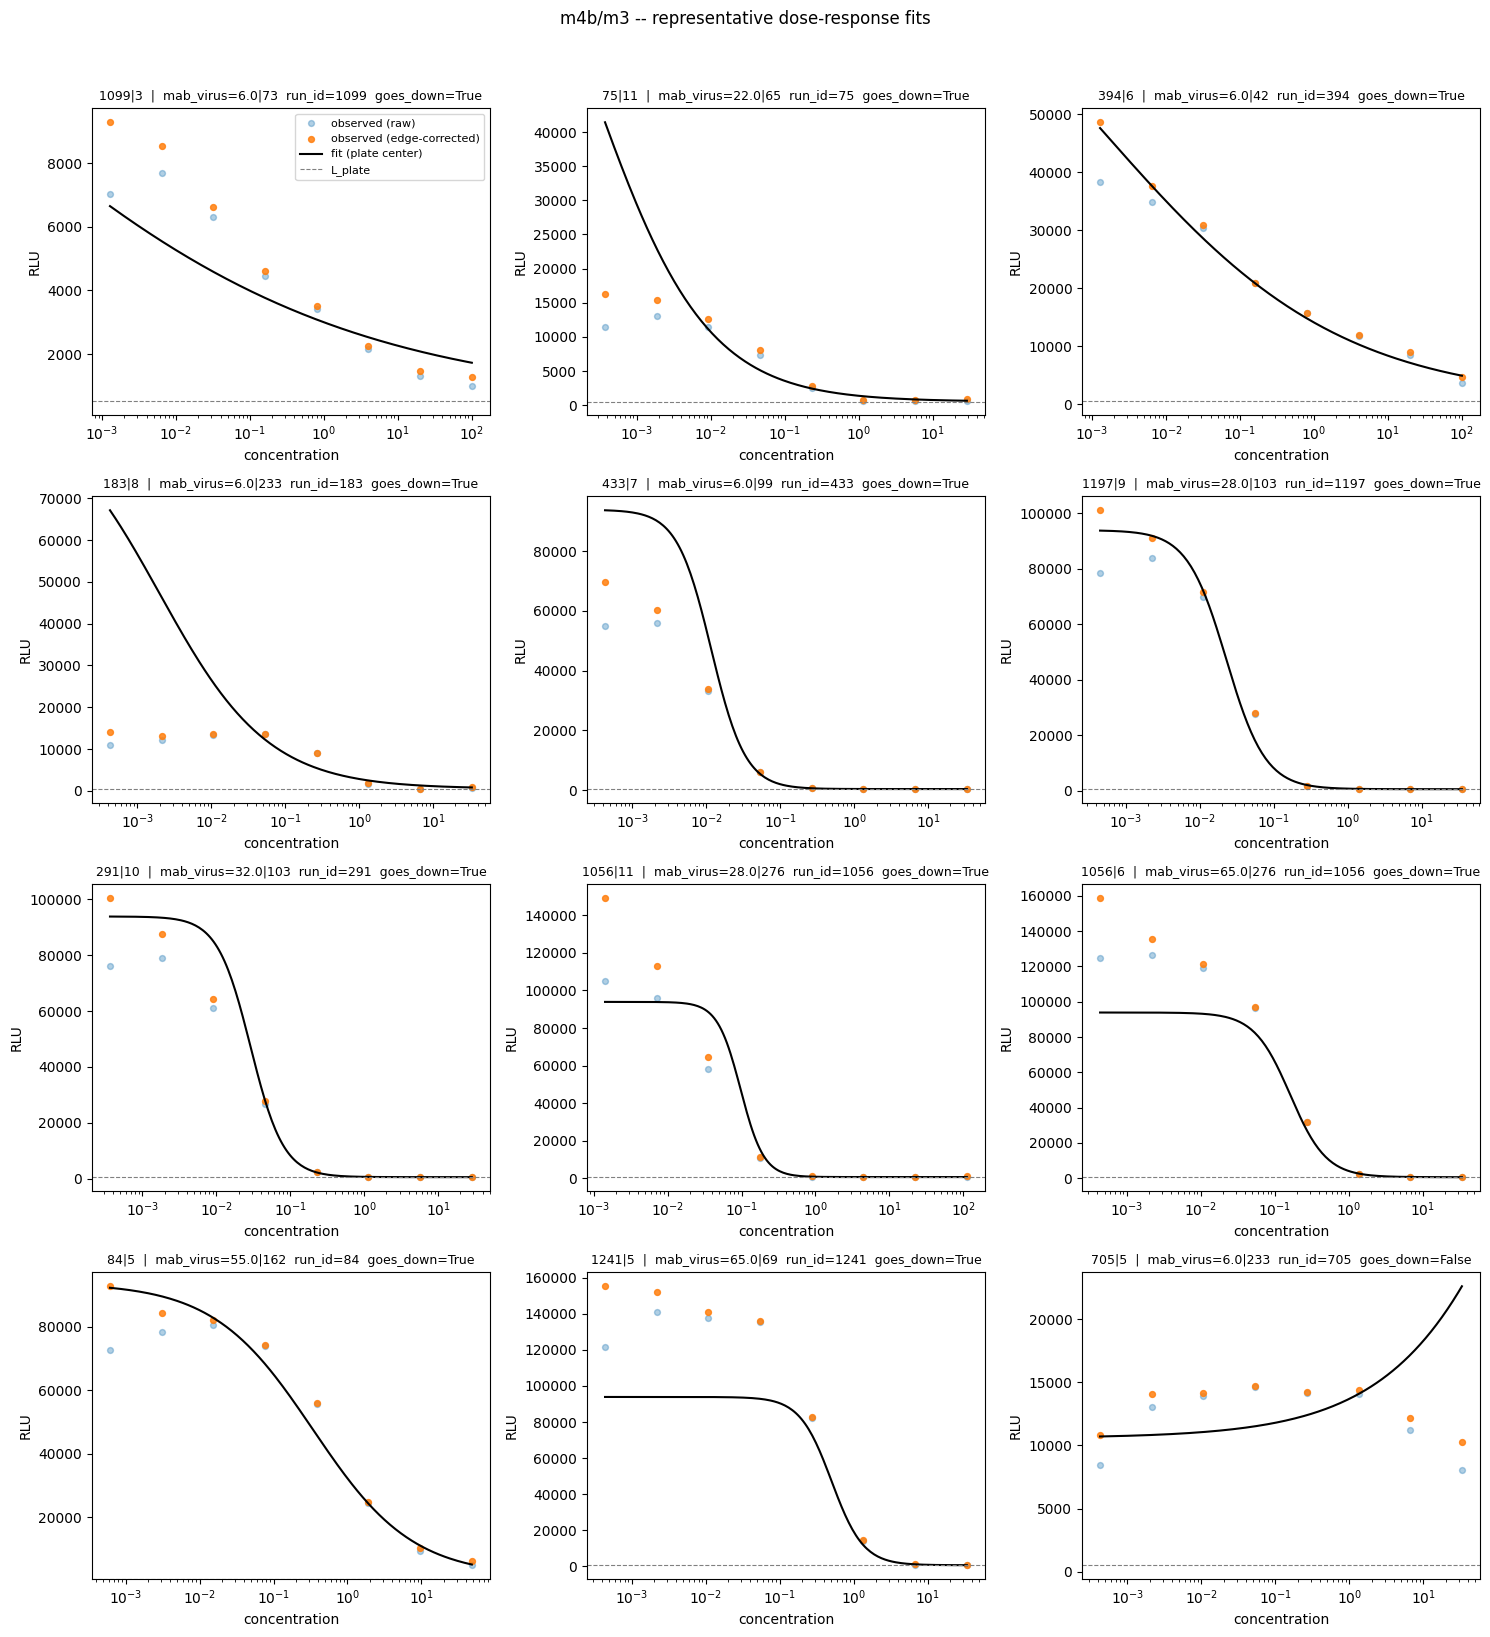

In [53]:
fig = plot_model("m4b/m3", n_ids=12)

saved /mnt/c/Users/bhaddock/repos/titration_pnlme/single_mabs/4PL_plate_fit_33_plates/v12/m5b_m3_fits.png


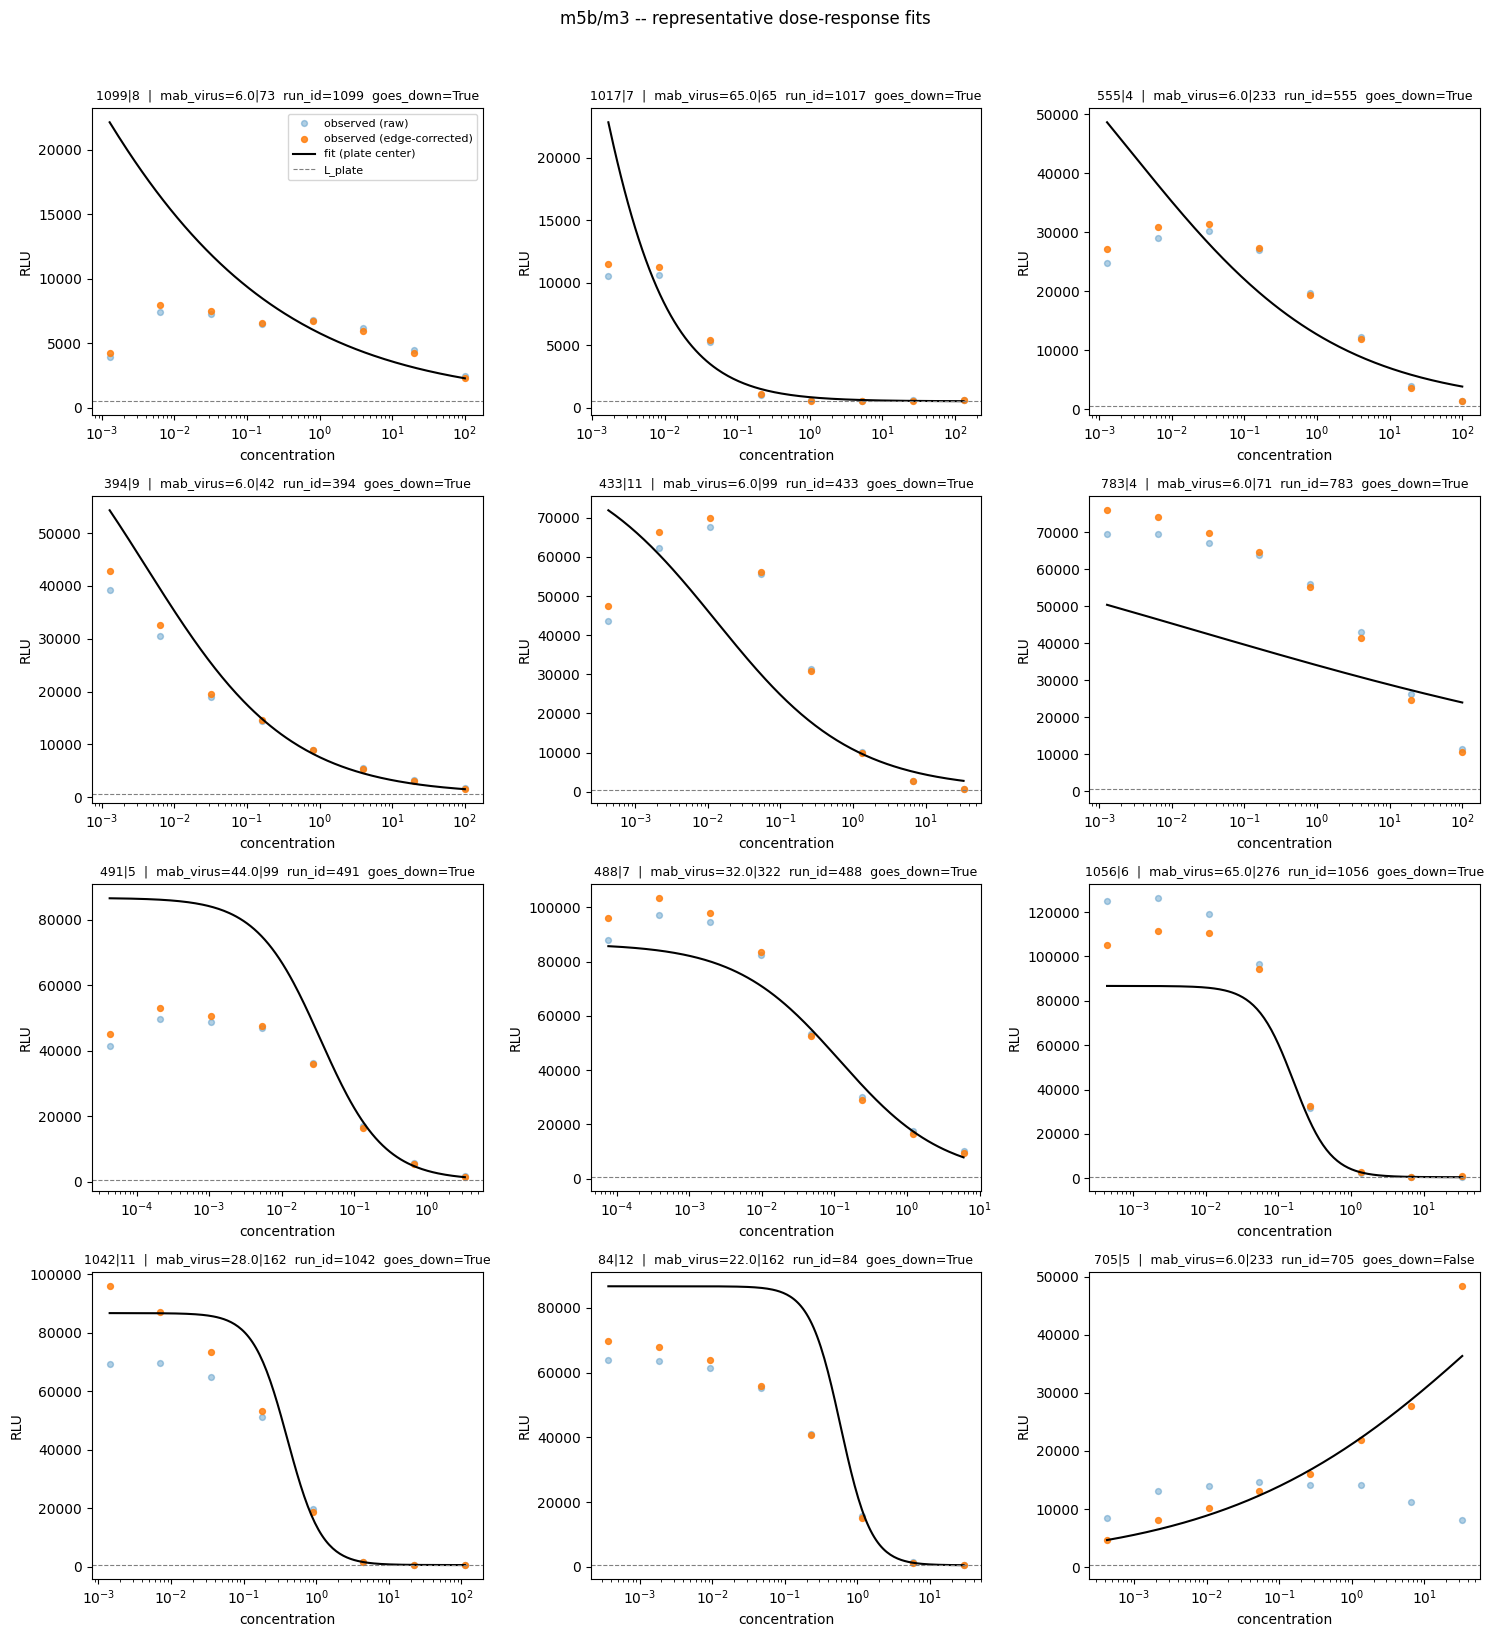

In [55]:
fig = plot_model("m5b/m3", n_ids=12)

## Ideas for mucking around
- Swap `pick_representative_ids` for `params.loc[valid_ids].sample(n, random_state=0)`, or hardcode a list of `id`s you actually care about (e.g. a specific mab_virus you're chasing a discrepancy on).
- Split by `goes_down` (0 vs 1) to sanity-check the covariate is doing something sensible.
- Once `m4b/m1` has real output, add it to `MODELS` above and everything else just works.
- `merge_model` also has the `binary_cc==1` (control) rows available if you drop that filter -- useful for checking `L_plate` against the actual control-well data instead of just the fitted line.
- Curious which ids got dropped as control/blank-only? `set(params.index) - set(sub['id'].unique())`.